# Single-Cell Pairing Analysis

This notebook validates the single-cell refactor and runs graph analysis for donors 1-4.

## 1. Notebook Runtime Guard in VS Code (`is_cell` default `True`)

The helper below keeps the `is_cell` check enabled by default and logs runtime per step.

In [1]:
# Runtime guard and shared imports.
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import polars as pl

from mir.common.single_cell import build_tenx_donor_from_cell_clonotypes, load_10x_vdj_v1_donor
from mir.common.single_cell_parser import load_10x_vdj_v1_cell_clonotypes
from mir.common.single_cell_repair import cleanup_cell_clonotypes, impute_missing_chains
from mir.common.single_cell_util import build_pairing_graph

SEED = 42


def run_step(name, fn, *args, is_cell=True, **kwargs):
    # This helper keeps notebook defaults explicit and reports runtime.
    t0 = time.perf_counter()
    result = fn(*args, check_is_cell=is_cell, **kwargs)
    dt = time.perf_counter() - t0
    print(f"{name}: {dt:.2f}s (check_is_cell={is_cell})")
    return result

print(f"cwd: {Path.cwd()}")
print(f"seed: {SEED}")

cwd: /Users/mikesh/vcs/mirpy/notebooks
seed: 42


## 2. Migrate `tcremp_10x_paired_analysis.ipynb` to `single_cell_load.ipynb`

The old notebook was renamed to `single_cell_load.ipynb`.

This section verifies donor file discovery and schema compatibility.

In [3]:
# Resolve donor input files and validate the parsed schema.
cwd = Path.cwd()
repo_root = cwd if (cwd / "mir").exists() else cwd.parent
base = repo_root / "notebooks" / "assets" / "large" / "airr_benchmark" / "dcode"

pairs = []
for all_contig in sorted(base.glob("*_all_contig_annotations.csv.gz")):
    consensus = base / all_contig.name.replace("_all_contig_annotations", "_consensus_annotations")
    if consensus.exists():
        donor_id = all_contig.name.split("_all_contig_annotations")[0]
        pairs.append((donor_id, consensus, all_contig))

print(f"donors found: {len(pairs)}")
for donor_id, _, _ in pairs[:4]:
    print(" -", donor_id)

if not pairs:
    raise RuntimeError(f"No donor pairs found under {base}")

first = pairs[0]
first_df = run_step(
    "load_cell_table_preview",
    load_10x_vdj_v1_cell_clonotypes,
    first[1],
    first[2],
    donor_id=first[0],
)
print(first_df.select(["barcode", "raw_pair_id", "sequence_id", "locus"]).head(5))

donors found: 4
 - vdj_v1_hs_aggregated_donor1
 - vdj_v1_hs_aggregated_donor2
 - vdj_v1_hs_aggregated_donor3
 - vdj_v1_hs_aggregated_donor4
load_cell_table_preview: 0.51s (check_is_cell=True)
shape: (5, 4)
┌─────────────────────┬───────────────┬───────────────────────────┬───────┐
│ barcode             ┆ raw_pair_id   ┆ sequence_id               ┆ locus │
│ ---                 ┆ ---           ┆ ---                       ┆ ---   │
│ str                 ┆ str           ┆ str                       ┆ str   │
╞═════════════════════╪═══════════════╪═══════════════════════════╪═══════╡
│ AAACCTGAGACAAAGG-4  ┆ clonotype19   ┆ clonotype19_consensus_1   ┆ TRB   │
│ AAACCTGAGACAAAGG-4  ┆ clonotype19   ┆ clonotype19_consensus_2   ┆ TRA   │
│ AAACCTGAGACAAAGG-4  ┆ clonotype19   ┆ clonotype19_consensus_3   ┆ TRA   │
│ AAACCTGAGACTGTAA-34 ┆ clonotype1318 ┆ clonotype1318_consensus_1 ┆ TRB   │
│ AAACCTGAGAGCCCAA-5  ┆ clonotype1319 ┆ clonotype1319_consensus_2 ┆ TRA   │
└─────────────────────┴───────────

## 3. Refactor Parsing and Single-Cell Processing Modules

Run a minimal end-to-end load using parser output + donor assembler to verify module compatibility.

In [4]:
# Build donor object from parsed table and compare to direct loader shape.
donor_id, cp, ap = pairs[0]
cell_table = run_step(
    "parse_cell_table",
    load_10x_vdj_v1_cell_clonotypes,
    cp,
    ap,
    donor_id=donor_id,
)
parsed_donor = build_tenx_donor_from_cell_clonotypes(cell_table, donor_id=donor_id)
direct_donor = run_step("direct_loader", load_10x_vdj_v1_donor, cp, ap, donor_id=donor_id)

print("parsed donor cells:", parsed_donor.loaded_cell_count)
print("direct donor cells:", direct_donor.loaded_cell_count)
print("parsed donor clonotypes:", parsed_donor.loaded_clonotype_count)
print("direct donor clonotypes:", direct_donor.loaded_clonotype_count)

parse_cell_table: 0.48s (check_is_cell=True)
direct_loader: 1.24s (check_is_cell=True)
parsed donor cells: 47271
direct donor cells: 47271
parsed donor clonotypes: 61298
direct donor clonotypes: 61298


## 4-7. Imputation, Cleanup, Pairing Graph, and Visualization

For each donor, compute raw, imputed, and cleanup tables, then render 3-panel pairing graphs.

In [5]:
# Build per-donor stage outputs and summary metrics.
CHAIN_COLORS = {
    "TRA": "#1f77b4",
    "TRB": "#ff7f0e",
    "TRG": "#2ca02c",
    "TRD": "#d62728",
    "IGH": "#9467bd",
    "IGK": "#8c564b",
    "IGL": "#e377c2",
}

stage_results = {}
summary_rows = []

for donor_id, cp, ap in pairs[:4]:
    raw = run_step(
        f"raw_parse_{donor_id}",
        load_10x_vdj_v1_cell_clonotypes,
        cp,
        ap,
        donor_id=donor_id,
    )
    imputed = impute_missing_chains(raw, seed=SEED)
    cleaned = cleanup_cell_clonotypes(imputed)

    raw_donor = build_tenx_donor_from_cell_clonotypes(raw, donor_id=donor_id)
    imp_donor = build_tenx_donor_from_cell_clonotypes(imputed, donor_id=donor_id)
    cln_donor = build_tenx_donor_from_cell_clonotypes(cleaned, donor_id=donor_id)

    raw_graph = build_pairing_graph(raw_donor)
    imp_graph = build_pairing_graph(imp_donor)
    cln_graph = build_pairing_graph(cln_donor)

    stage_results[donor_id] = {
        "raw": raw_graph,
        "imputed": imp_graph,
        "cleanup": cln_graph,
    }

    for stage, table in [("raw", raw), ("imputed", imputed), ("cleanup", cleaned)]:
        graph = stage_results[donor_id][stage]
        summary_rows.append(
            {
                "donor_id": donor_id,
                "stage": stage,
                "cell_rows": table.height,
                "nodes": graph.nodes.height,
                "edges": graph.edges.height,
            }
        )

summary_df = pl.DataFrame(summary_rows).sort(["donor_id", "stage"])
summary_df

raw_parse_vdj_v1_hs_aggregated_donor1: 0.52s (check_is_cell=True)
raw_parse_vdj_v1_hs_aggregated_donor2: 0.63s (check_is_cell=True)
raw_parse_vdj_v1_hs_aggregated_donor3: 0.53s (check_is_cell=True)
raw_parse_vdj_v1_hs_aggregated_donor4: 0.41s (check_is_cell=True)


donor_id,stage,cell_rows,nodes,edges
str,str,i64,i64,i64
"""vdj_v1_hs_aggregated_donor1""","""cleanup""",100250,66053,35752
"""vdj_v1_hs_aggregated_donor1""","""imputed""",102610,68245,38743
"""vdj_v1_hs_aggregated_donor1""","""raw""",95663,56312,31458
"""vdj_v1_hs_aggregated_donor2""","""cleanup""",163532,54942,34336
"""vdj_v1_hs_aggregated_donor2""","""imputed""",168351,58220,38849
…,…,…,…,…
"""vdj_v1_hs_aggregated_donor3""","""imputed""",81080,41818,24472
"""vdj_v1_hs_aggregated_donor3""","""raw""",77033,35411,20259
"""vdj_v1_hs_aggregated_donor4""","""cleanup""",57493,35138,18894


KeyboardInterrupt: 

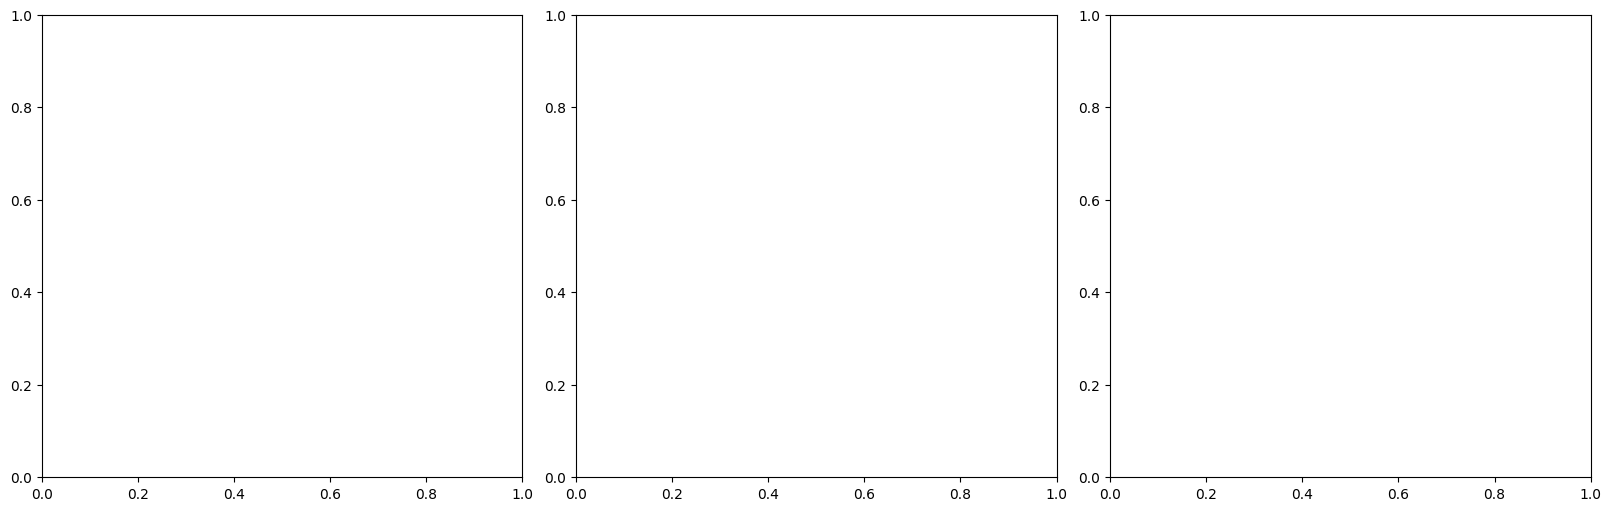

In [6]:
# Plot graph panels for each donor and stage.
def _to_networkx(pairing_graph):
    g = nx.Graph()
    nodes = pairing_graph.nodes.to_dicts()
    edges = pairing_graph.edges.to_dicts()
    for row in nodes:
        g.add_node(
            row["node_id"],
            locus=row["locus"],
            color=CHAIN_COLORS.get(row["locus"], "#7f7f7f"),
        )
    for row in edges:
        g.add_edge(row["source"], row["target"], weight=row["cell_count"])
    return g


def _plot_graph(ax, g, title):
    if g.number_of_nodes() == 0:
        ax.set_title(f"{title} (empty)")
        ax.axis("off")
        return
    pos = nx.spring_layout(g, seed=SEED, weight="weight")
    node_colors = [g.nodes[n].get("color", "#7f7f7f") for n in g.nodes]
    widths = [max(0.5, 0.2 * float(g[u][v].get("weight", 1))) for u, v in g.edges]
    nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=90, ax=ax, alpha=0.9)
    nx.draw_networkx_edges(g, pos, width=widths, alpha=0.35, ax=ax)
    ax.set_title(title)
    ax.axis("off")


for donor_id in sorted(stage_results):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    for ax, stage in zip(axes, ["raw", "imputed", "cleanup"]):
        g = _to_networkx(stage_results[donor_id][stage])
        _plot_graph(ax, g, f"{donor_id}\n{stage}")
    fig.suptitle(f"Pairing graphs for {donor_id}")
    plt.show()

legend_handles = []
for locus, color in CHAIN_COLORS.items():
    legend_handles.append(plt.Line2D([0], [0], marker="o", color="w", label=locus, markerfacecolor=color, markersize=8))

fig, ax = plt.subplots(figsize=(9, 1.2))
ax.legend(handles=legend_handles, ncol=7, loc="center", frameon=False)
ax.axis("off")
plt.show()

## 8. Run Unit Tests for Sanity Checks

Use VS Code tests when possible; terminal fallback command is shown for quick reruns.

In [ ]:
# Show test command for terminal fallback.
print("Run in terminal from repo root:")
print("python -m pytest tests/test_single_cell.py tests/test_single_cell_repair.py -q")

## 9. Documentation and SKILL Update Checklist

- Added parser/repair/util modules for single-cell workflows.
- Added default `check_is_cell=True` parameter to donor loading.
- Added test coverage for filtering, imputation, cleanup, and pairing graph behavior.
- Added this notebook for raw/imputed/cleanup pairing graph comparison.
- Updated docs and skill guide with new APIs and notebook names.